# Laboratorio 7 — Introducción al deep learning con PyTorch

**Natural Language Processing**

En este laboratorio se implementan con PyTorch las ideas vistas en la clase de introducción al deep learning. Cada sección usa un módulo distinto de PyTorch:

| Sección | Módulo principal |
|---|---|
| 1. Redes multicapa | `nn.Module`, `nn.Linear` |
| 2. Funciones de activación | `torch.autograd` |
| 3. Ciclo de entrenamiento | `nn.CrossEntropyLoss`, `torch.optim` |
| 4. Etiquetado POS con RNN | `nn.Embedding`, `nn.LSTM`, `nn.RNN` |
| 9. Conclusiones | — |

Todo corre en CPU.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# Semilla global para que los resultados sean reproducibles
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device("cpu")
print("PyTorch", torch.__version__)

PyTorch 2.14.1


# 1. Redes multicapa con `nn.Module`

El perceptrón simple no puede resolver XOR porque las dos clases no son linealmente separables: no existe una recta que deje (0,1) y (1,0) de un lado y (0,0) y (1,1) del otro. Aquí se resuelve con un perceptrón multicapa (MLP).

In [2]:
# Datos de XOR: 4 puntos y su etiqueta
X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = torch.tensor([[0.], [1.], [1.], [0.]])

### 1.1 Definición del MLP

`MLP` hereda de `nn.Module`: en `__init__` se declaran las capas (sus pesos quedan registrados automáticamente como parámetros) y en `forward` se describe cómo fluye la entrada. La salida es un *logit*; la sigmoide la aplica `nn.BCEWithLogitsLoss` internamente.

In [3]:
class MLP(nn.Module):
    def __init__(self, n_in=2, n_hidden=8, n_out=1, activation=True):
        super().__init__()
        self.hidden = nn.Linear(n_in, n_hidden)
        # Si activation=False la red queda como dos capas lineales apiladas
        self.act = nn.Tanh() if activation else nn.Identity()
        self.out = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        h = self.act(self.hidden(x))
        return self.out(h)


def train_xor(model, epochs=2000, lr=0.05):
    """Entrena sobre XOR y se detiene al llegar a 100% de exactitud (si lo logra)."""
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        logits = model(X_xor)
        loss = loss_fn(logits, y_xor)
        loss.backward()
        optimizer.step()
        acc = ((logits > 0).float() == y_xor).float().mean().item()
        if acc == 1.0 and loss.item() < 0.05:
            break
    return epoch, loss.item(), acc


torch.manual_seed(SEED)
mlp = MLP(activation=True)
epoch, loss, acc = train_xor(mlp)
print(f"MLP con tanh -> época {epoch}, pérdida {loss:.4f}, exactitud {acc:.0%}")

with torch.no_grad():
    probs = torch.sigmoid(mlp(X_xor)).squeeze()
pd.DataFrame({"x1": X_xor[:, 0].int(), "x2": X_xor[:, 1].int(),
              "y real": y_xor.squeeze().int(), "P(y=1)": probs.numpy().round(3),
              "predicción": (probs > 0.5).int()})

MLP con tanh -> época 38, pérdida 0.0483, exactitud 100%


,x1,x2,y real,P(y=1),predicción
0,0,0,0,0.021,0
1,0,1,1,0.935,1
2,1,0,1,0.968,1
3,1,1,0,0.046,0


### 1.2 Frontera de decisión

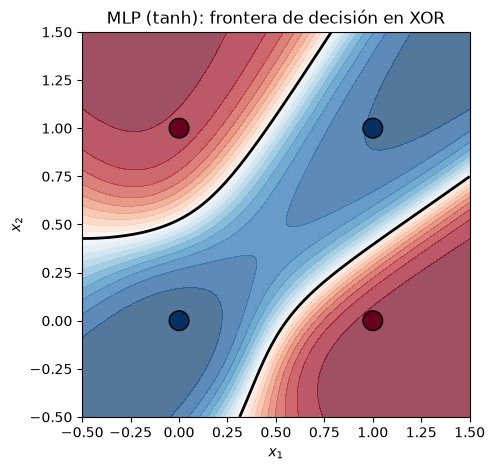

In [4]:
def plot_boundary(model, ax, title):
    xx, yy = torch.meshgrid(torch.linspace(-0.5, 1.5, 300), torch.linspace(-0.5, 1.5, 300), indexing="xy")
    grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)
    with torch.no_grad():
        zz = torch.sigmoid(model(grid)).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.7)
    ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.squeeze(), cmap="RdBu_r",
               edgecolors="k", s=200, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")


fig, ax = plt.subplots(figsize=(5, 5))
plot_boundary(mlp, ax, "MLP (tanh): frontera de decisión en XOR")
plt.show()

### 1.3 La misma red sin función de activación

MLP sin activación -> 5000 épocas, pérdida 0.6931, exactitud 50%
P(y=1) para cada punto: [0.5 0.5 0.5 0.5]


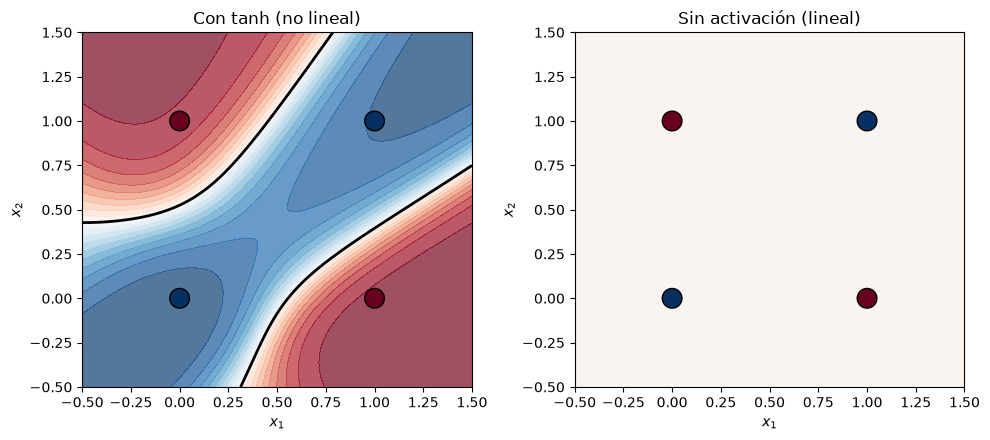

In [5]:
torch.manual_seed(SEED)
mlp_lineal = MLP(activation=False)
epoch, loss, acc = train_xor(mlp_lineal, epochs=5000)
print(f"MLP sin activación -> {epoch} épocas, pérdida {loss:.4f}, exactitud {acc:.0%}")

with torch.no_grad():
    print("P(y=1) para cada punto:", torch.sigmoid(mlp_lineal(X_xor)).squeeze().numpy().round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_boundary(mlp, axes[0], "Con tanh (no lineal)")
plot_boundary(mlp_lineal, axes[1], "Sin activación (lineal)")
plt.tight_layout()
plt.show()

Se puede verificar numéricamente que las dos capas lineales colapsan en una sola: si $h = W_1x + b_1$ y $y = W_2h + b_2$, entonces

$$y = W_2(W_1x + b_1) + b_2 = \underbrace{(W_2W_1)}_{W}\,x + \underbrace{(W_2b_1 + b_2)}_{b}$$

In [6]:
W1, b1 = mlp_lineal.hidden.weight, mlp_lineal.hidden.bias
W2, b2 = mlp_lineal.out.weight, mlp_lineal.out.bias

# Una única capa lineal equivalente
W = W2 @ W1
b = W2 @ b1 + b2
with torch.no_grad():
    salida_red = mlp_lineal(X_xor)
    salida_una_capa = X_xor @ W.T + b
print("W equivalente:", W.detach().numpy().round(4), " b:", b.detach().numpy().round(4))
print("¿Mismas salidas?", torch.allclose(salida_red, salida_una_capa, atol=1e-6))

W equivalente: [[0. 0.]]  b: [0.]
¿Mismas salidas? True


**¿Por qué no resuelve XOR la red sin activación?**

Sin una función no lineal entre las capas, la composición de dos transformaciones afines es otra transformación afín: $W = W_2W_1$ y $b = W_2b_1 + b_2$ (la celda anterior lo confirma, las salidas son idénticas). Por lo tanto, aunque la red tenga 8 neuronas ocultas, su frontera de decisión sigue siendo una recta, exactamente igual que la del perceptrón. Como XOR no es linealmente separable, lo mejor que puede hacer el optimizador es minimizar la pérdida asignando $P(y=1)=0.5$ a los cuatro puntos: la pérdida se estanca en $\ln 2 \approx 0.693$, los pesos efectivos tienden a cero (panel derecho uniforme) y la exactitud queda en 50%.

Con `tanh` la capa oculta deforma el espacio de entrada de manera no lineal; en ese espacio transformado los puntos sí son separables por la capa de salida, y al regresar al plano original la frontera aparece como dos curvas que aíslan las esquinas (0,1) y (1,0).

**Conclusión:** la profundidad sola no basta; lo que da poder expresivo es la combinación de capas **con** activaciones no lineales.

### 1.4 Red de la diapositiva: 3 → 4 → 4 → 2

In [7]:
class RedDiapositiva(nn.Module):
    def __init__(self):
        super().__init__()
        self.capa1 = nn.Linear(3, 4)
        self.capa2 = nn.Linear(4, 4)
        self.salida = nn.Linear(4, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.capa1(x))
        x = self.act(self.capa2(x))
        return self.salida(x)


red = RedDiapositiva()
total = sum(p.numel() for p in red.parameters())
print(f"Total de parámetros: {total}")
print("Cálculo a mano: (3·4 + 4) + (4·4 + 4) + (4·2 + 2) =", (3*4 + 4) + (4*4 + 4) + (4*2 + 2))

Total de parámetros: 46
Cálculo a mano: (3·4 + 4) + (4·4 + 4) + (4·2 + 2) = 46


In [8]:
pd.DataFrame(
    [(name, tuple(p.shape), p.numel()) for name, p in red.named_parameters()],
    columns=["Parámetro", "Forma", "Elementos"],
)

,Parámetro,Forma,Elementos
0,capa1.weight,"(4, 3)",12
1,capa1.bias,"(4,)",4
2,capa2.weight,"(4, 4)",16
3,capa2.bias,"(4,)",4
4,salida.weight,"(2, 4)",8
5,salida.bias,"(2,)",2


# 2. Funciones de activación

Se calculan sigmoide, tanh y ReLU sobre un mismo tensor y se obtienen sus derivadas con **autograd**, sin escribir las fórmulas a mano.

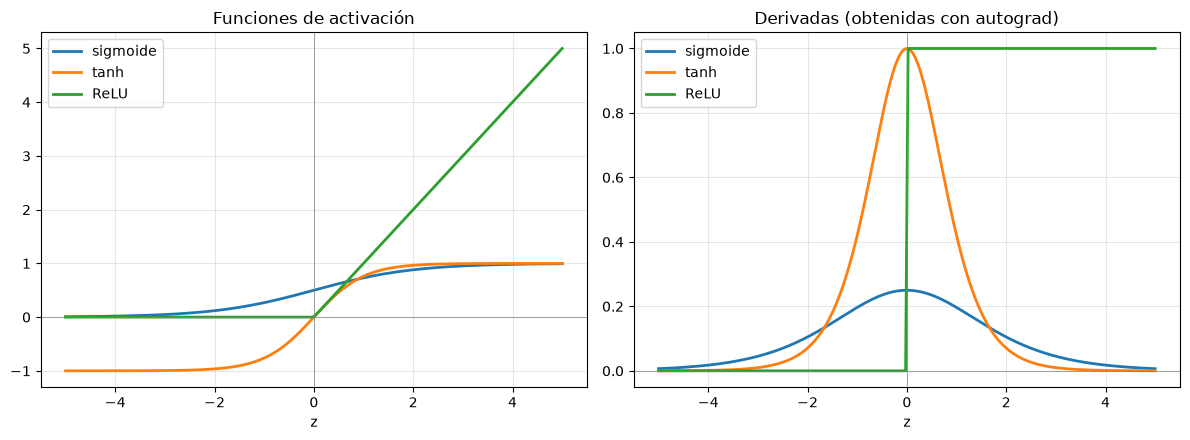

In [9]:
z = torch.linspace(-5, 5, 200, requires_grad=True)

activaciones = {
    "sigmoide": torch.sigmoid,
    "tanh": torch.tanh,
    "ReLU": torch.relu,
}

valores, derivadas = {}, {}
for nombre, f in activaciones.items():
    y = f(z)
    # Como cada salida depende solo de su z_i, el gradiente de la suma es la derivada punto a punto
    (grad,) = torch.autograd.grad(y.sum(), z)
    valores[nombre] = y.detach()
    derivadas[nombre] = grad

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
z_np = z.detach()
for nombre in activaciones:
    ax1.plot(z_np, valores[nombre], label=nombre, lw=2)
    ax2.plot(z_np, derivadas[nombre], label=nombre, lw=2)
ax1.set_title("Funciones de activación")
ax2.set_title("Derivadas (obtenidas con autograd)")
for ax in (ax1, ax2):
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlabel("z")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Valores puntuales de las derivadas para apoyar el análisis
puntos = [-5.0, -2.5, 0.0, 2.5, 5.0]
idx = [int(torch.argmin((z_np - p).abs())) for p in puntos]
tabla = pd.DataFrame(
    {nombre: [derivadas[nombre][i].item() for i in idx] for nombre in activaciones},
    index=[f"z ≈ {z_np[i]:.2f}" for i in idx],
)
tabla.round(4)

,sigmoide,tanh,ReLU
z ≈ -5.00,0.0066,0.0002,0.0
z ≈ -2.49,0.0709,0.0273,0.0
z ≈ -0.03,0.2500,0.9994,0.0
z ≈ 2.49,0.0709,0.0273,1.0
z ≈ 5.00,0.0066,0.0002,1.0


### Análisis de las derivadas

**¿Dónde se desvanece el gradiente de la sigmoide y de tanh?** En las colas, es decir, cuando $|z|$ es grande (en la práctica desde $|z| \gtrsim 2.5$). Ambas funciones se saturan: la sigmoide se aplana cerca de 0 y 1, y tanh cerca de −1 y 1. En esas regiones la derivada es prácticamente cero (en $z=\pm5$ vale 0.0066 para la sigmoide y 0.0002 para tanh). Además, la derivada de la sigmoide **nunca supera 0.25** (su máximo, en $z=0$). Como en backpropagation los gradientes se multiplican capa por capa, en una red profunda un producto de factores ≤ 0.25 se va encogiendo exponencialmente y las primeras capas casi no aprenden. tanh es algo mejor porque su derivada llega a 1 en el origen y su salida está centrada en cero, pero se satura incluso más rápido que la sigmoide.

**¿Por qué ReLU es la opción por defecto en capas ocultas?**
- Su derivada es exactamente **1 para todo $z>0$**: no se satura en la parte positiva, así que el gradiente pasa sin atenuarse por muchas capas.
- Es muy barata de calcular (un `max(0, z)`), sin exponenciales.
- Produce activaciones dispersas (muchas neuronas en 0), lo que suele funcionar como una forma de regularización.

Su desventaja es que la derivada es 0 para $z<0$: una neurona que siempre recibe entradas negativas deja de actualizarse ("ReLU muerta"). Variantes como Leaky ReLU o GELU atacan ese problema, pero ReLU sigue siendo el punto de partida estándar. La sigmoide se reserva para la salida de clasificación binaria y tanh aparece dentro de las celdas recurrentes (como en la LSTM de la sección 4).